# LLM Inference Scheduler Visualization

Six plots comparing scheduler runs over time:
1. Cumulative Energy (J)
2. Per-Interval Energy (J)
3. Energy per Token (J/token)
4. Tokens Generated per Interval
5. GPU Temperature (°C)
6. Token Throughput (tokens/s)

Each file in `RUNS` becomes one line per plot.

In [24]:
# ============================================================
#  CONFIGURATION — edit this cell to add/remove runs
# ============================================================
RUNS = [
    {"file": "../results/real_static.json",               "label": "Static"},
    # {"file": "../results/real_runtime.json",     "label": "Runtime (balanced)"},
    {"file": "../results/real_runtime-conservative.json", "label": "Runtime (conservative)"},
    # {"file": "../results/real_runtime-aggressive.json",   "label": "Runtime (aggressive)"},
    # {"file": "../results/real_runtime_coldstart.json",    "label": "Runtime (cold start)"},
]

# Output directory for saved figures
FIG_DIR = "figures"

# Interval length in seconds (must match your benchmark config)
INTERVAL_S = 10.0

# ── Toggle event/decision overlays ──────────────────────────
SHOW_PHASE_TRANSITIONS = True   # gray dashed lines: decode↔prefill workload changes
SHOW_SCENARIO_EVENTS   = True   # colored lines: thermal spike (red), load spike (blue)
SHOW_DECISION_MARKERS  = True   # shaded regions for non-routine runtime decisions

# ── Colors — one per run (extend if you have more than 8) ───
PALETTE = [
    "#2196F3",  # blue
    "#F44336",  # red
    "#4CAF50",  # green
    "#FF9800",  # orange
    "#9C27B0",  # purple
    "#00BCD4",  # cyan
    "#795548",  # brown
    "#607D8B",  # blue-grey
]

# ── Decision category → (color, label) ──────────────────────
# Reasons are grouped: any key starting with the dict key is matched
DECISION_CATEGORIES = {
    "exploring_candidate":  ("#FF9800", "Exploring candidate"),   # orange
    "kept_explored_config": ("#8BC34A", "Kept explored config"),  # light green
    "goodput_degraded":     ("#F44336", "Goodput degraded"),       # red
    "ept_degraded":         ("#9C27B0", "EPT degraded"),           # purple
    "reverted_to_prior":    ("#00BCD4", "Reverted to prior"),      # cyan
}

# ── Scenario event → (color, label) for vertical lines ──────
EVENT_STYLES = {
    "thermal_spike":  ("#F44336", "Thermal spike"),   # red
    "cooling_event":  ("#2196F3", "Cooling event"),   # blue
    "load_spike":     ("#2196F3", "Load spike"),       # blue
}

In [25]:
# ============================================================
#  IMPORTS
# ============================================================
import json
import os
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

os.makedirs(FIG_DIR, exist_ok=True)
matplotlib.rcParams.update({
    "figure.dpi":      150,
    "font.size":       11,
    "axes.titlesize":  13,
    "axes.labelsize":  11,
    "legend.fontsize": 9,
    "lines.linewidth": 2,
})

In [26]:
# ============================================================
#  DATA LOADING
# ============================================================

def load_run(entry):
    """
    Load a single run file and return a structured dict with:
      - label        : display name
      - is_sim       : True if meta.mode == "sim"
      - times        : list of sim_time values
      - cum_energy   : cumulative energy in joules
      - interval_energy : per-interval energy in joules
      - energy_per_token
      - tokens
      - throughput   : tokens / INTERVAL_S
      - temperature  : mean GPU temp per interval
      - scheduler    : "static" or "runtime"
      - scenario     : raw scenario list (may be empty)
      - decisions    : raw decisions list (may be empty)
    """
    with open(entry["file"]) as f:
        raw = json.load(f)

    meta      = raw.get("meta", {})
    sched_key = next(k for k in raw if k != "meta")
    sched     = raw[sched_key]
    obs       = sched["observations"]

    times             = [o["sim_time"] for o in obs]
    interval_energy   = [sum(o["gpu_energy_j"].values()) for o in obs]
    cum_energy        = list(np.cumsum(interval_energy))
    energy_per_token  = [o["energy_per_token_j"] for o in obs]
    tokens            = [o["tokens_generated"] for o in obs]
    throughput        = [t / INTERVAL_S for t in tokens]
    temperature       = [
        sum(o["gpu_temp_c"].values()) / len(o["gpu_temp_c"])
        for o in obs
    ]

    return {
        "label":           entry["label"],
        "is_sim":          meta.get("mode", "") == "sim",
        "times":           times,
        "cum_energy":      cum_energy,
        "interval_energy": interval_energy,
        "energy_per_token":energy_per_token,
        "tokens":          tokens,
        "throughput":      throughput,
        "temperature":     temperature,
        "scheduler":       sched_key,
        "scenario":        meta.get("scenario", []),
        "decisions":       sched.get("decisions", []),
    }


# Load all runs — adding a new file to RUNS is all that's needed
runs = [load_run(e) for e in RUNS]
print(f"Loaded {len(runs)} runs:")
for r in runs:
    print(f"  [{r['scheduler']:8s}] {r['label']:35s}  "
          f"n_obs={len(r['times'])}  is_sim={r['is_sim']}  "
          f"decisions={len(r['decisions'])}")

Loaded 2 runs:
  [static  ] Static                               n_obs=36  is_sim=False  decisions=18
  [runtime ] Runtime (conservative)               n_obs=36  is_sim=False  decisions=36


In [27]:
# ============================================================
#  OVERLAY HELPERS
# ============================================================

def categorize_decision(reason):
    """Map a raw decision reason string to a category key, or None to skip."""
    for key in DECISION_CATEGORIES:
        if reason.startswith(key):
            return key
    return None  # pareto_select, exploit → skip


def draw_scenario_overlays(ax, scenario, is_sim):
    """
    Draw vertical lines for scenario events and phase transitions.
    Only draws event lines for sim mode; phase transitions follow
    SHOW_PHASE_TRANSITIONS regardless of mode.
    """
    for entry in scenario:
        t, kind, cfg = entry[0], entry[1], entry[2]

        if kind == "event" and SHOW_SCENARIO_EVENTS and is_sim:
            event_name = cfg.get("event", "")
            style = EVENT_STYLES.get(event_name)
            if style:
                color, _ = style
                ax.axvline(t, color=color, linewidth=1.5,
                           linestyle="--", alpha=0.8, zorder=3)

        elif kind == "workload" and SHOW_PHASE_TRANSITIONS:
            if t > 0:  # skip t=0 (initial setup, not a transition)
                ax.axvline(t, color="gray", linewidth=1.0,
                           linestyle="--", alpha=0.5, zorder=2)


def draw_decision_markers(ax, run, ymin, ymax):
    """
    Draw semi-transparent vertical spans for non-routine decisions.
    Skipped entirely for static schedulers.
    """
    if not SHOW_DECISION_MARKERS:
        return
    if run["scheduler"] == "static":
        return

    half = INTERVAL_S / 2
    for dec in run["decisions"]:
        reason = dec.get("reason", "")
        cat    = categorize_decision(reason)
        if cat is None:
            continue
        color, _ = DECISION_CATEGORIES[cat]
        t = dec["sim_time"]
        ax.axvspan(t - half, t + half,
                   color=color, alpha=0.15, zorder=1)


def build_legend_handles(runs_plotted):
    """
    Build a combined legend: one entry per run line, plus overlay entries
    for any scenario events / decision categories that actually appear.
    """
    handles = []

    # Run lines
    for run, color in runs_plotted:
        handles.append(Line2D([0], [0], color=color, linewidth=2,
                               label=run["label"]))

    # Phase transition line (if toggled on and any run has workload entries)
    has_transitions = SHOW_PHASE_TRANSITIONS and any(
        any(e[1] == "workload" and e[0] > 0 for e in r["scenario"])
        for r, _ in runs_plotted
    )
    if has_transitions:
        handles.append(Line2D([0], [0], color="gray", linewidth=1,
                               linestyle="--", alpha=0.6,
                               label="Phase transition"))

    # Scenario event lines (sim only)
    if SHOW_SCENARIO_EVENTS:
        seen_events = set()
        for run, _ in runs_plotted:
            if not run["is_sim"]:
                continue
            for entry in run["scenario"]:
                if entry[1] == "event":
                    name = entry[2].get("event", "")
                    if name in EVENT_STYLES and name not in seen_events:
                        color, label = EVENT_STYLES[name]
                        handles.append(Line2D([0], [0], color=color,
                                               linewidth=1.5, linestyle="--",
                                               alpha=0.8, label=label))
                        seen_events.add(name)

    # Decision category patches (runtime only)
    if SHOW_DECISION_MARKERS:
        seen_cats = set()
        for run, _ in runs_plotted:
            if run["scheduler"] == "static":
                continue
            for dec in run["decisions"]:
                cat = categorize_decision(dec.get("reason", ""))
                if cat and cat not in seen_cats:
                    color, label = DECISION_CATEGORIES[cat]
                    handles.append(mpatches.Patch(
                        facecolor=color, alpha=0.35, label=label))
                    seen_cats.add(cat)

    return handles

In [28]:
# ============================================================
#  CORE PLOT FUNCTION
# ============================================================

def make_plot(runs, metric_key, title, ylabel, filename,
              ymin=None, ymax=None):
    """
    Draw one line-graph figure.

    Parameters
    ----------
    runs        : list of run dicts from load_run()
    metric_key  : key in run dict holding the y-values list
    title       : figure title
    ylabel      : y-axis label
    filename    : stem used for saved file (no extension)
    ymin/ymax   : optional y-axis limits
    """
    fig, ax = plt.subplots(figsize=(11, 5))

    runs_plotted = []
    for run, color in zip(runs, PALETTE):
        ax.plot(run["times"], run[metric_key],
                color=color, label=run["label"],
                linewidth=2, marker="o", markersize=3, zorder=5)
        runs_plotted.append((run, color))

    # Use first run's scenario for overlays (all runs share same scenario)
    # Decision markers are drawn per-run so each run's events appear
    ref_run = runs[0]
    _ymin = ymin if ymin is not None else ax.get_ylim()[0]
    _ymax = ymax if ymax is not None else ax.get_ylim()[1]

    draw_scenario_overlays(ax, ref_run["scenario"], ref_run["is_sim"])
    for run in runs:
        draw_decision_markers(ax, run, _ymin, _ymax)

    if ymin is not None or ymax is not None:
        ax.set_ylim(ymin, ymax)

    ax.set_xlabel("Simulation time (s)")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, linestyle=":", alpha=0.5)

    handles = build_legend_handles(runs_plotted)
    ax.legend(handles=handles, loc="best",
              framealpha=0.85, edgecolor="#cccccc")

    fig.tight_layout()
    plt.show()
    return fig


print("Plot function defined.")

Plot function defined.


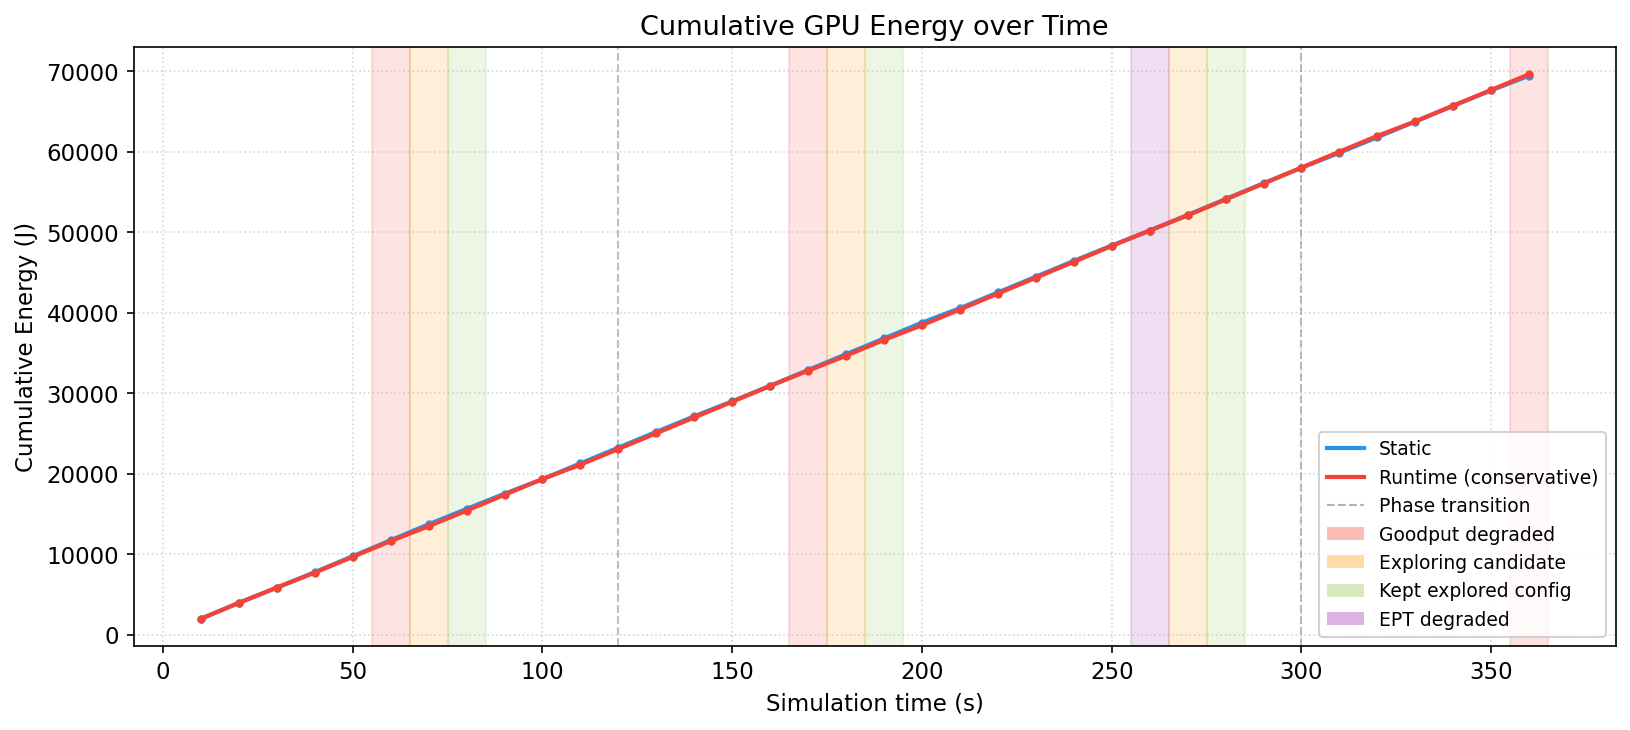

In [29]:
# ============================================================
#  PLOT 1 — Cumulative Energy
# ============================================================
fig_cum_energy = make_plot(
    runs,
    metric_key = "cum_energy",
    title      = "Cumulative GPU Energy over Time",
    ylabel     = "Cumulative Energy (J)",
    filename   = "01_cumulative_energy",
)

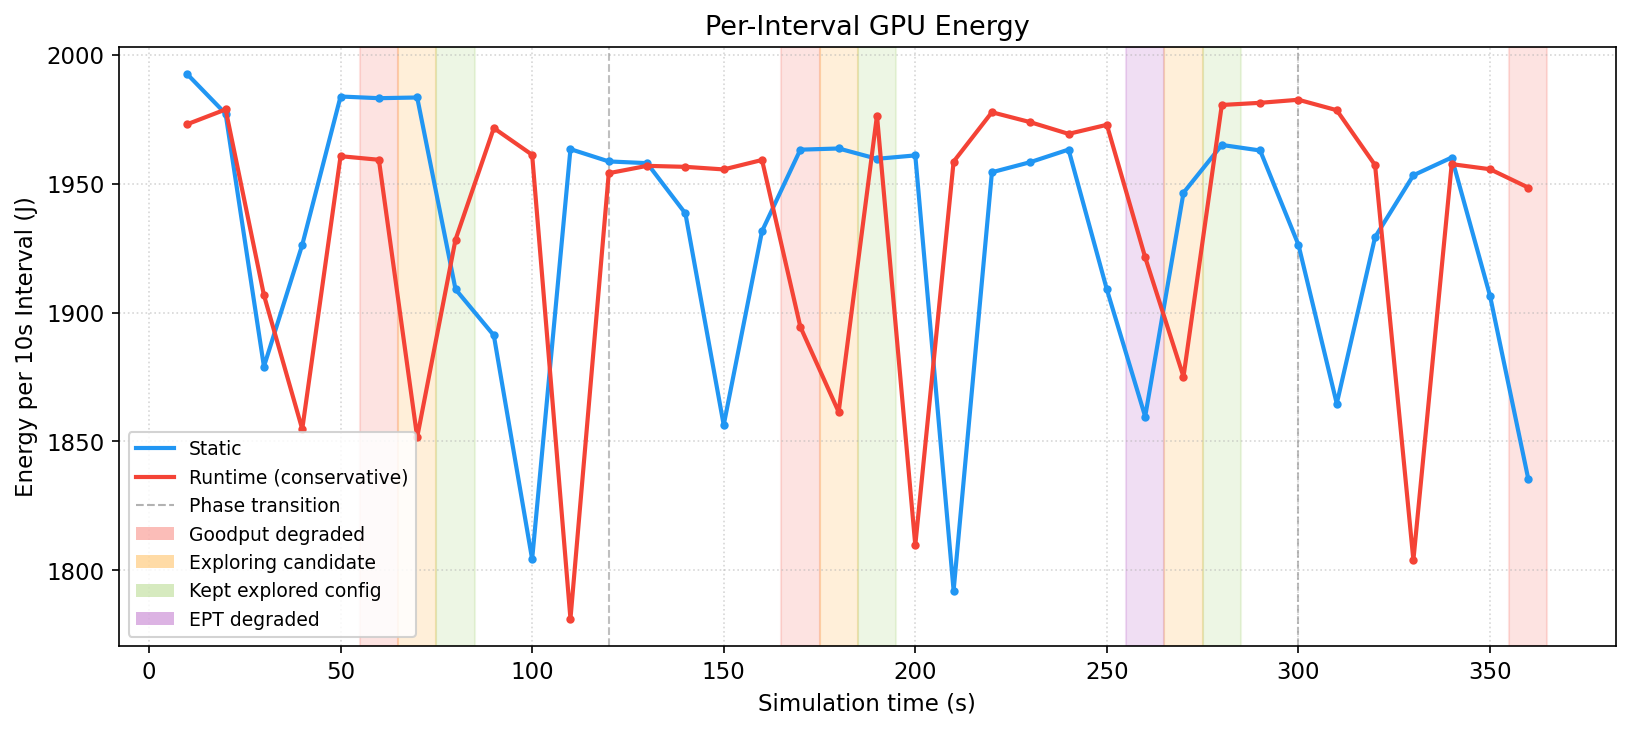

In [30]:
# ============================================================
#  PLOT 2 — Per-Interval Energy
# ============================================================
fig_interval_energy = make_plot(
    runs,
    metric_key = "interval_energy",
    title      = "Per-Interval GPU Energy",
    ylabel     = f"Energy per {int(INTERVAL_S)}s Interval (J)",
    filename   = "02_interval_energy",
)

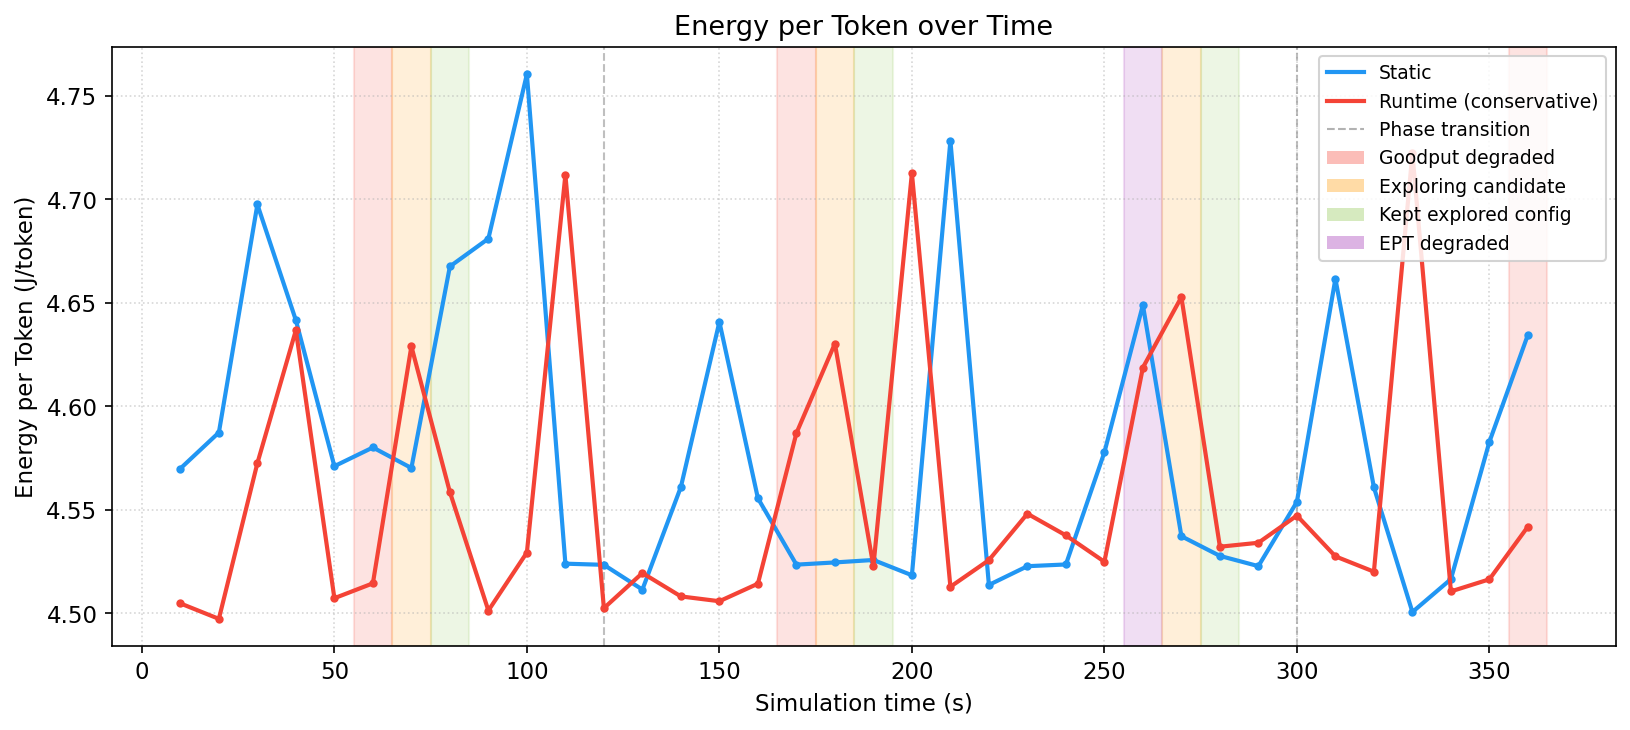

In [31]:
# ============================================================
#  PLOT 3 — Energy per Token
# ============================================================
fig_ept = make_plot(
    runs,
    metric_key = "energy_per_token",
    title      = "Energy per Token over Time",
    ylabel     = "Energy per Token (J/token)",
    filename   = "03_energy_per_token",
)

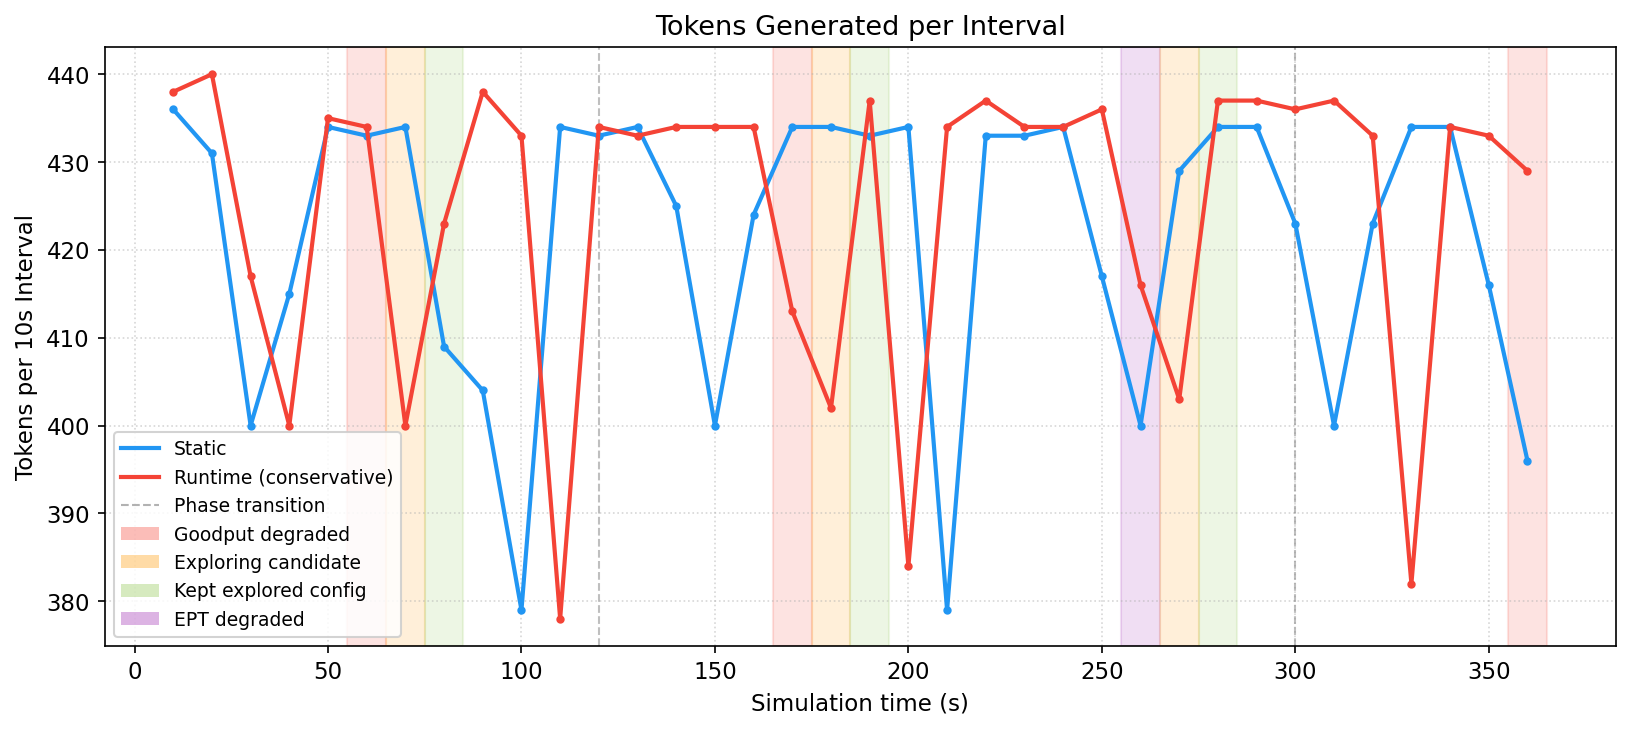

In [32]:
# ============================================================
#  PLOT 4 — Tokens Generated per Interval
# ============================================================
fig_tokens = make_plot(
    runs,
    metric_key = "tokens",
    title      = "Tokens Generated per Interval",
    ylabel     = f"Tokens per {int(INTERVAL_S)}s Interval",
    filename   = "04_tokens_per_interval",
)

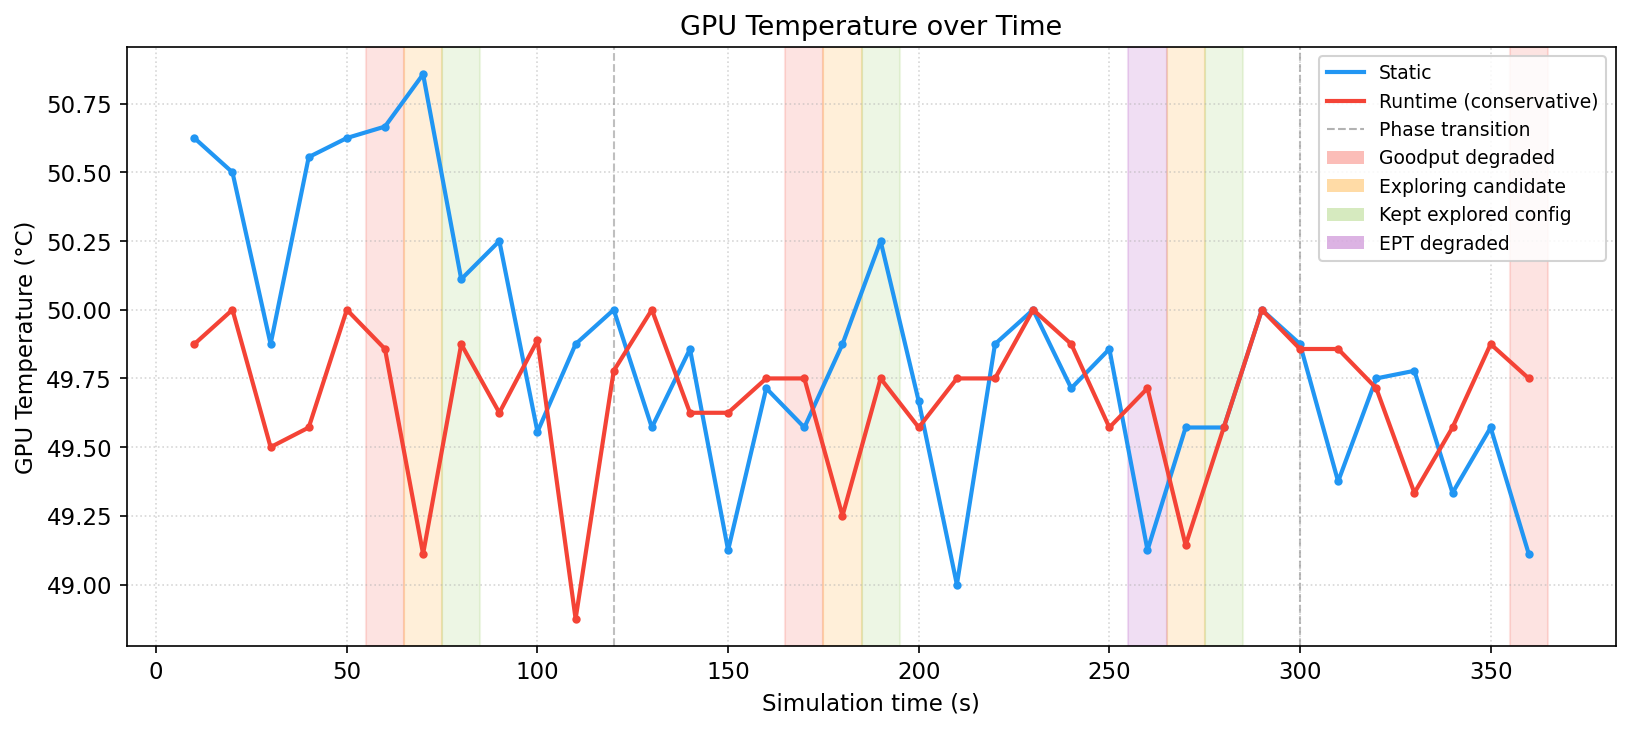

In [33]:
# ============================================================
#  PLOT 5 — GPU Temperature
# ============================================================
fig_temp = make_plot(
    runs,
    metric_key = "temperature",
    title      = "GPU Temperature over Time",
    ylabel     = "GPU Temperature (°C)",
    filename   = "05_temperature",
)

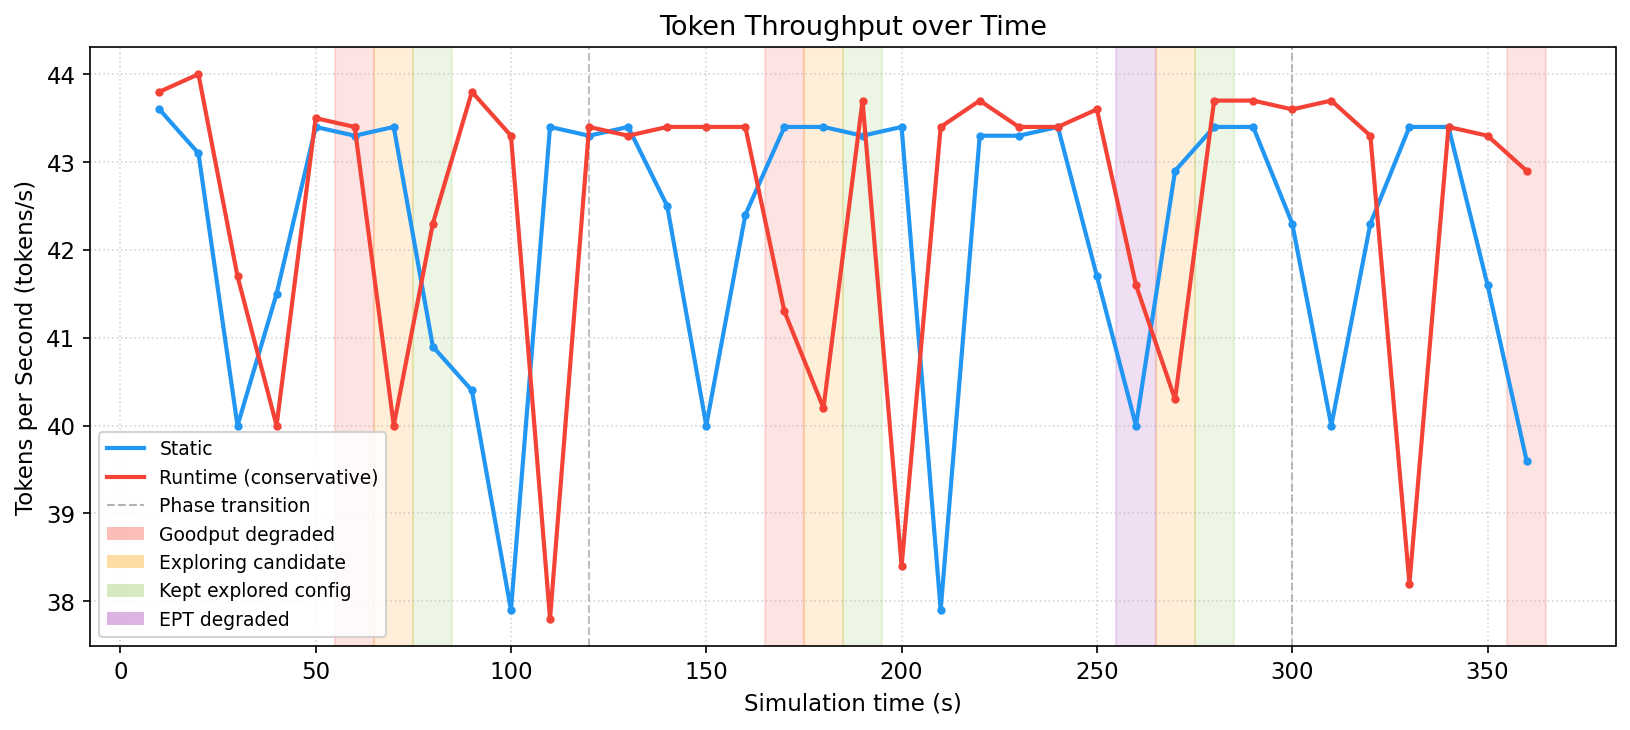

In [34]:
# ============================================================
#  PLOT 6 — Token Throughput (proxy for goodput)
# ============================================================
fig_throughput = make_plot(
    runs,
    metric_key = "throughput",
    title      = "Token Throughput over Time",
    ylabel     = "Tokens per Second (tokens/s)",
    filename   = "06_token_throughput",
)

In [35]:
# ============================================================
#  SAVE ALL FIGURES  (run this cell separately when needed)
# ============================================================
save_map = {
    "01_cumulative_energy":  fig_cum_energy,
    "02_interval_energy":    fig_interval_energy,
    "03_energy_per_token":   fig_ept,
    "04_tokens_per_interval":fig_tokens,
    "05_temperature":        fig_temp,
    "06_token_throughput":   fig_throughput,
}

for stem, fig in save_map.items():
    for ext in ("png", "pdf"):
        path = os.path.join(FIG_DIR, f"{stem}.{ext}")
        fig.savefig(path, bbox_inches="tight")
        print(f"Saved {path}")

Saved figures/01_cumulative_energy.png
Saved figures/01_cumulative_energy.pdf
Saved figures/02_interval_energy.png
Saved figures/02_interval_energy.pdf
Saved figures/03_energy_per_token.png
Saved figures/03_energy_per_token.pdf
Saved figures/04_tokens_per_interval.png
Saved figures/04_tokens_per_interval.pdf
Saved figures/05_temperature.png
Saved figures/05_temperature.pdf
Saved figures/06_token_throughput.png
Saved figures/06_token_throughput.pdf
